## Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Dataset and augmentation

In [3]:
# Emotion mapping
EMOTIONS = {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}

# ==========================================
# 1. DATASET
# ==========================================
class CremaDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        spec = np.load(file_path)
        spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
        spec = np.expand_dims(spec, axis=0) 
        spec_tensor = torch.tensor(spec, dtype=torch.float32)
        
        filename = os.path.basename(file_path)
        emotion_code = filename.split('_')[2]
        label = EMOTIONS[emotion_code]
        
        return spec_tensor, torch.tensor(label, dtype=torch.long)
    
# ==========================================
# 2. DATASET WITH AUGMENTATION
# ==========================================

# Data Augmentation: Standard deviation of Gaussian noise added to spectrograms.
# Try ranges: 0.001 (very subtle) to 0.01 (noticeable static)
ADD_NOISE_STD = 0.005

# SpecAugment Masking: Max number of bins to randomly blackout.
# Try ranges: Freq (10-30), Time (20-50)
FREQ_MASK_PARAM = 10 #15
TIME_MASK_PARAM = 20 #30

class CremaDatasetAugmented(Dataset):
    def __init__(self, file_paths, is_train=False):
        self.file_paths = file_paths
        self.is_train = is_train # Only apply augmentation to the training set!
       
    def __len__(self):
        return len(self.file_paths)
       
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        spec = np.load(file_path)
        spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
       
        # --- DATA AUGMENTATION (Frequency & Time Masking) ---
        if self.is_train:
            n_mels, n_steps = spec.shape
           
            # Frequency masking (horizontal blackout)
            if n_mels > FREQ_MASK_PARAM:
                f_mask = np.random.randint(0, FREQ_MASK_PARAM)
                f0 = np.random.randint(0, n_mels - f_mask)
                spec[f0:f0 + f_mask, :] = 0
               
            # Time masking (vertical blackout)
            if n_steps > TIME_MASK_PARAM:
                t_mask = np.random.randint(0, TIME_MASK_PARAM)
                t0 = np.random.randint(0, n_steps - t_mask)
                spec[:, t0:t0 + t_mask] = 0

        spec = np.expand_dims(spec, axis=0)
        spec_tensor = torch.tensor(spec, dtype=torch.float32)
       
        # --- DATA AUGMENTATION (Gaussian Noise) ---
        if self.is_train:
            noise = torch.randn_like(spec_tensor) * ADD_NOISE_STD
            spec_tensor = spec_tensor + noise
       
        filename = os.path.basename(file_path)
        emotion_code = filename.split('_')[2]
        label = EMOTIONS[emotion_code]
       
        return spec_tensor, torch.tensor(label, dtype=torch.long)

# ConvNeXt-Tiny no pretraining
no augmentation, regularization, 

Actors -> Train: 72, Val: 9, Test: 10
Epoch 1/20 | Train Acc: 28.95% | Val Acc: 34.01%
Epoch 2/20 | Train Acc: 36.98% | Val Acc: 36.86%
Epoch 3/20 | Train Acc: 38.25% | Val Acc: 38.21%
Epoch 4/20 | Train Acc: 40.36% | Val Acc: 39.57%
Epoch 5/20 | Train Acc: 41.41% | Val Acc: 39.84%
Epoch 6/20 | Train Acc: 42.56% | Val Acc: 39.30%
Epoch 7/20 | Train Acc: 43.57% | Val Acc: 41.60%
Epoch 8/20 | Train Acc: 44.84% | Val Acc: 37.13%
Epoch 9/20 | Train Acc: 45.84% | Val Acc: 42.95%
Epoch 10/20 | Train Acc: 47.47% | Val Acc: 40.79%
Epoch 11/20 | Train Acc: 50.29% | Val Acc: 44.72%
Epoch 12/20 | Train Acc: 51.68% | Val Acc: 43.77%
Epoch 13/20 | Train Acc: 54.35% | Val Acc: 42.41%
Epoch 14/20 | Train Acc: 56.71% | Val Acc: 42.68%
Epoch 15/20 | Train Acc: 59.64% | Val Acc: 42.82%
Epoch 16/20 | Train Acc: 62.55% | Val Acc: 43.50%
Epoch 17/20 | Train Acc: 67.05% | Val Acc: 42.41%
Epoch 18/20 | Train Acc: 70.92% | Val Acc: 44.85%
Epoch 19/20 | Train Acc: 76.16% | Val Acc: 42.14%
Epoch 20/20 | Train A

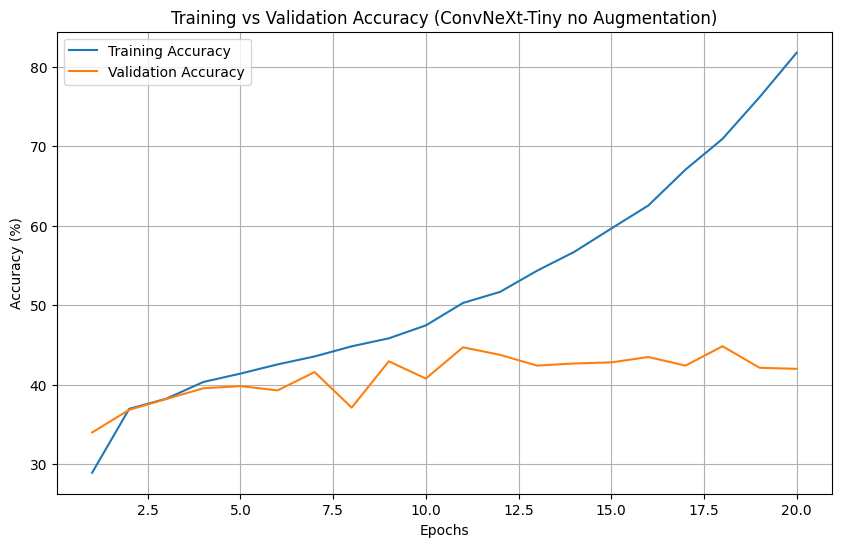


Final Test Accuracy (Unseen Actors): 44.72%


In [9]:
# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. DATA SPLITTING (Actor-Based)
spec_path = "./features/mel_spectrograms"
all_files = [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

unique_actors = list(set([os.path.basename(f).split('_')[0] for f in all_files]))
unique_actors.sort() # Ensure consistency

# First, split off the training set (80%)
train_actors, temp_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)
# Split the remaining 20% into Val and Test (50/50 of the remainder = 10% each of total)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.5, random_state=42)

print(f"Actors -> Train: {len(train_actors)}, Val: {len(val_actors)}, Test: {len(test_actors)}")

train_files = [f for f in all_files if os.path.basename(f).split('_')[0] in train_actors]
val_files = [f for f in all_files if os.path.basename(f).split('_')[0] in val_actors]
test_files = [f for f in all_files if os.path.basename(f).split('_')[0] in test_actors]

train_loader = DataLoader(CremaDataset(train_files), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CremaDataset(val_files), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CremaDataset(test_files), batch_size=BATCH_SIZE, shuffle=False)

# 2. MODEL SETUP
model = models.convnext_tiny(weights=None)
model.features[0][0] = nn.Conv2d(
    1, 96, kernel_size=(4, 4), stride=(4, 4)
)
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Linear(num_ftrs, len(EMOTIONS))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE) # AdamW is preferred for ConvNeXt

# Lists to store metrics for plotting
history = {
    'train_acc': [],
    'val_acc': []
}

# 3. TRAINING LOOP
for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_acc = 100. * train_correct / train_total
    
    # --- Validation Phase ---
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_acc = 100. * val_correct / val_total
    
    # Save metrics
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

# 4. PLOTTING
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Training Accuracy', marker='')
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Validation Accuracy', marker='')
plt.title('Training vs Validation Accuracy (ConvNeXt-Tiny no Augmentation)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# 5. FINAL TEST
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Accuracy (Unseen Actors): {100. * test_correct / test_total:.2f}%")

# ConvNeXt-Tiny with Pretraining


Actors -> Train: 72, Val: 9, Test: 10
Epoch 1/10 | Train Acc: 36.01% | Val Acc: 38.35%
Epoch 2/10 | Train Acc: 45.82% | Val Acc: 46.07%
Epoch 3/10 | Train Acc: 51.75% | Val Acc: 44.85%
Epoch 4/10 | Train Acc: 59.46% | Val Acc: 48.37%
Epoch 5/10 | Train Acc: 66.69% | Val Acc: 50.81%
Epoch 6/10 | Train Acc: 76.50% | Val Acc: 50.54%
Epoch 7/10 | Train Acc: 85.50% | Val Acc: 51.49%
Epoch 8/10 | Train Acc: 91.29% | Val Acc: 54.34%
Epoch 9/10 | Train Acc: 95.35% | Val Acc: 55.01%
Epoch 10/10 | Train Acc: 95.55% | Val Acc: 54.34%


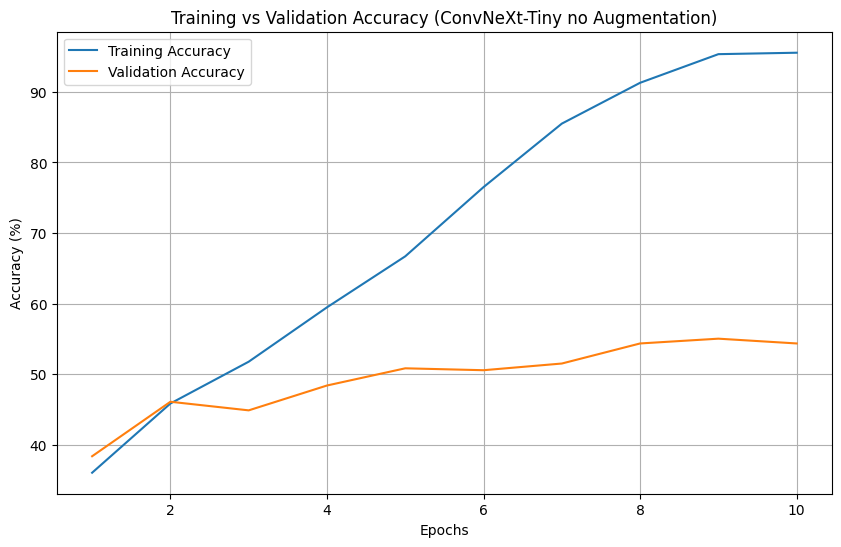


Final Test Accuracy (Unseen Actors): 57.00%


In [5]:
# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. DATA SPLITTING (Actor-Based)
spec_path = "./features/mel_spectrograms"
all_files = [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

unique_actors = list(set([os.path.basename(f).split('_')[0] for f in all_files]))
unique_actors.sort() # Ensure consistency

# First, split off the training set (80%)
train_actors, temp_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)
# Split the remaining 20% into Val and Test (50/50 of the remainder = 10% each of total)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.5, random_state=42)

print(f"Actors -> Train: {len(train_actors)}, Val: {len(val_actors)}, Test: {len(test_actors)}")

train_files = [f for f in all_files if os.path.basename(f).split('_')[0] in train_actors]
val_files = [f for f in all_files if os.path.basename(f).split('_')[0] in val_actors]
test_files = [f for f in all_files if os.path.basename(f).split('_')[0] in test_actors]

train_loader = DataLoader(CremaDataset(train_files), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CremaDataset(val_files), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CremaDataset(test_files), batch_size=BATCH_SIZE, shuffle=False)

# 2. MODEL SETUP
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
model.features[0][0] = nn.Conv2d(
    1, 96, kernel_size=(4, 4), stride=(4, 4)
)
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Linear(num_ftrs, len(EMOTIONS))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE) # AdamW is preferred for ConvNeXt

# Lists to store metrics for plotting
history = {
    'train_acc': [],
    'val_acc': []
}

# 3. TRAINING LOOP
for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_acc = 100. * train_correct / train_total
    
    # --- Validation Phase ---
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_acc = 100. * val_correct / val_total
    
    # Save metrics
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

# 4. PLOTTING
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Training Accuracy', marker='')
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Validation Accuracy', marker='')
plt.title('Training vs Validation Accuracy (ConvNeXt-Tiny no Augmentation)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# 5. FINAL TEST
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Accuracy (Unseen Actors): {100. * test_correct / test_total:.2f}%")

# Pretrained ConvNeXt-Tiny with regularization
Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Actors -> Train: 72, Val: 9, Test: 10
Epoch 1/20 | Train Acc: 17.44% | Val Acc: 14.63%
Epoch 2/20 | Train Acc: 27.20% | Val Acc: 35.91%
Epoch 3/20 | Train Acc: 38.10% | Val Acc: 38.75%
Epoch 4/20 | Train Acc: 41.09% | Val Acc: 41.60%
Epoch 5/20 | Train Acc: 44.09% | Val Acc: 43.77%
Epoch 6/20 | Train Acc: 45.53% | Val Acc: 42.01%
Epoch 7/20 | Train Acc: 47.93% | Val Acc: 44.04%
Epoch 8/20 | Train Acc: 50.03% | Val Acc: 47.70%
Epoch 9/20 | Train Acc: 53.23% | Val Acc: 49.46%
Epoch 10/20 | Train Acc: 56.47% | Val Acc: 53.79%
Epoch 11/20 | Train Acc: 59.54% | Val Acc: 51.22%
Epoch 12/20 | Train Acc: 63.33% | Val Acc: 55.15%
Epoch 13/20 | Train Acc: 65.03% | Val Acc: 54.07%
Epoch 14/20 | Train Acc: 68.15% | Val Acc: 55.56%
Epoch 15/20 | Train Acc: 73.26% | Val Acc: 53.52%
Epoch 16/20 | Train Acc: 77.16% | Val Acc: 55.83%
Epoch 17/20 | Train Acc: 81.31% | Val Acc: 55.56%
Epoch 18/20 | Train Acc: 83.07% | Val Acc: 53.12%
Epoch 19/20 | Train Acc: 85.74% | Val Acc: 51.49%
Epoch 20/20 | Train A

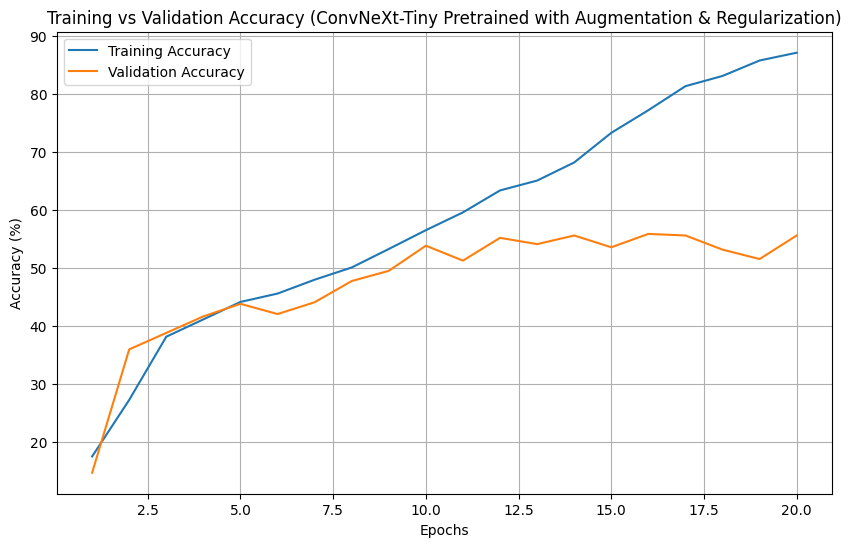


Final Test Accuracy (Unseen Actors): 55.77%


In [9]:
# ==========================================
# 1. HYPERPARAMETERS & REGULARIZATION TUNING
# ==========================================
BATCH_SIZE = 32
EPOCHS = 20 # You might need slightly more epochs now that training is harder
LEARNING_RATE = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Regularization Parameters ---
# Weight Decay (L2): Pulls weights towards zero to prevent extreme memorization.
# Try ranges: 1e-5 (light) to 1e-3 (heavy)
WEIGHT_DECAY = 1e-3 #1e-4

# Label Smoothing: Prevents the model from being 100% certain about its predictions.
# Try ranges: 0.05 (light) to 0.2 (heavy)
LABEL_SMOOTHING = 0.1

# Dropout: Percentage of neurons to randomly zero out in the final layer.
# Try ranges: 0.3 to 0.6
DROPOUT_RATE = 0.5

# ==========================================
# 2. DATA SPLITTING
# ==========================================
spec_path = "./features/mel_spectrograms"
all_files = [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

unique_actors = list(set([os.path.basename(f).split('_')[0] for f in all_files]))
unique_actors.sort()

train_actors, temp_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.5, random_state=42)

print(f"Actors -> Train: {len(train_actors)}, Val: {len(val_actors)}, Test: {len(test_actors)}")

train_files = [f for f in all_files if os.path.basename(f).split('_')[0] in train_actors]
val_files = [f for f in all_files if os.path.basename(f).split('_')[0] in val_actors]
test_files = [f for f in all_files if os.path.basename(f).split('_')[0] in test_actors]

# Notice we pass is_train=True ONLY to the train loader
train_loader = DataLoader(CremaDatasetAugmented(train_files, is_train=True), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CremaDatasetAugmented(val_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CremaDatasetAugmented(test_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3. MODEL SETUP WITH DROPOUT
# ==========================================

# 1. LOAD PRETRAINED CONVNEXT-TINY
# Weights from ImageNet-1K (Version 1)
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# 2. ADAPT THE INPUT STEM (The "conv1" equivalent)
# ConvNeXt-Tiny's first layer is features[0][0]
# It's a Conv2d with 96 output channels, kernel_size=(4,4), stride=(4,4)
model.features[0][0] = nn.Conv2d(
    1, 96, 
    kernel_size=(4, 4), 
    stride=(4, 4)
)

# 3. ADAPT THE CLASSIFIER HEAD
# ConvNeXt.classifier is a Sequential: LayerNorm -> Flatten -> Linear
# We will insert Dropout before the final Linear layer (index 2)
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(num_ftrs, len(EMOTIONS))
)

model = model.to(DEVICE)

# 4. LOSS & OPTIMIZER
# Keep Label Smoothing as requested
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# SWITCH TO ADAMW: Strongly recommended for ConvNeXt architectures
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# Lists to store metrics for plotting
history = {
    'train_acc': [],
    'val_acc': []
}


# ==========================================
# 4. TRAINING LOOP
# ==========================================
for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
   
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
       
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
       
    epoch_train_acc = 100. * train_correct / train_total
   
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
           
    epoch_val_acc = 100. * val_correct / val_total
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
   
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

# ==========================================
# 5. PLOTTING & EVALUATION
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Training Accuracy', marker='')
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Validation Accuracy', marker='')
plt.title('Training vs Validation Accuracy (ConvNeXt-Tiny Pretrained with Augmentation & Regularization)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Accuracy (Unseen Actors): {100. * test_correct / test_total:.2f}%")

# Pretrained ConvNeXt-Tiny with regularization and learning rate decay

Epoch 1/20 | Train: 17.16% | Val: 17.07% | LR: 0.000100
Epoch 2/20 | Train: 30.46% | Val: 33.60% | LR: 0.000100
Epoch 3/20 | Train: 38.74% | Val: 39.43% | LR: 0.000100
Epoch 4/20 | Train: 41.68% | Val: 40.65% | LR: 0.000100
Epoch 5/20 | Train: 44.47% | Val: 38.48% | LR: 0.000100
Epoch 6/20 | Train: 45.89% | Val: 44.72% | LR: 0.000100
Epoch 7/20 | Train: 47.95% | Val: 40.51% | LR: 0.000100
Epoch 8/20 | Train: 49.71% | Val: 45.66% | LR: 0.000100
Epoch 9/20 | Train: 52.46% | Val: 45.53% | LR: 0.000100
Epoch 10/20 | Train: 56.23% | Val: 50.00% | LR: 0.000100
Epoch 11/20 | Train: 59.68% | Val: 50.00% | LR: 0.000100
Epoch 12/20 | Train: 63.28% | Val: 51.08% | LR: 0.000100
Epoch 13/20 | Train: 64.97% | Val: 50.81% | LR: 0.000100
Epoch 14/20 | Train: 70.48% | Val: 49.86% | LR: 0.000100
Epoch 15/20 | Train: 73.40% | Val: 50.68% | LR: 0.000050
Epoch 16/20 | Train: 81.38% | Val: 50.68% | LR: 0.000050
Epoch 17/20 | Train: 85.16% | Val: 51.49% | LR: 0.000050
Epoch 18/20 | Train: 86.40% | Val: 51.08

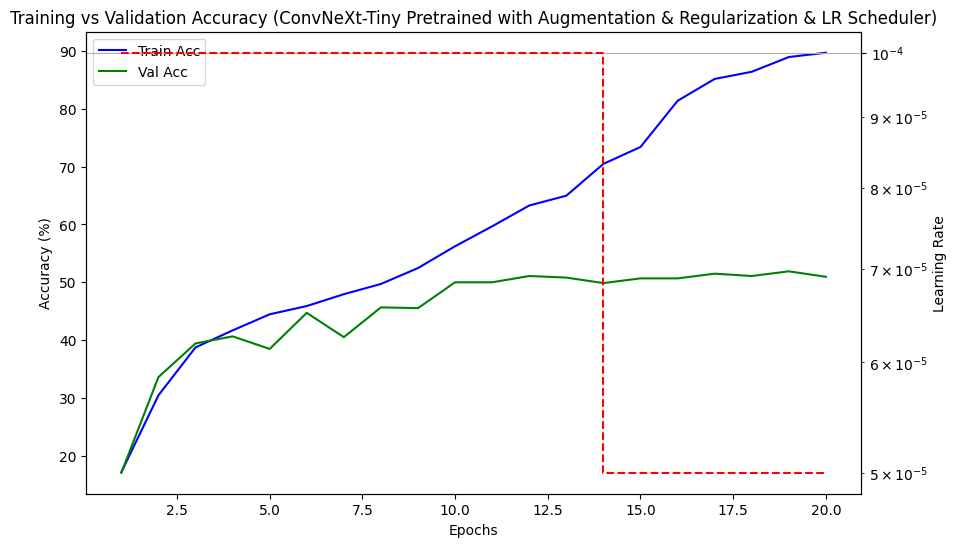


Final Test Accuracy (Unseen Actors): 56.39%


In [10]:
# ==========================================
# 1. HYPERPARAMETERS & REGULARIZATION TUNING
# ==========================================
BATCH_SIZE = 32
EPOCHS = 20 
LEARNING_RATE = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Regularization Parameters ---
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.1
DROPOUT_RATE = 0.5

# --- Scheduler Parameters ---
# Factor: multiply LR by this (0.5 = cut in half)
# Patience: wait this many epochs with no improvement before dropping
SCHEDULER_FACTOR = 0.5    
SCHEDULER_PATIENCE = 2    

# ==========================================
# 2. DATA SPLITTING 
# ==========================================
spec_path = "./features/mel_spectrograms"
all_files = [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

unique_actors = list(set([os.path.basename(f).split('_')[0] for f in all_files]))
unique_actors.sort() 

train_actors, temp_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.5, random_state=42)

train_files = [f for f in all_files if os.path.basename(f).split('_')[0] in train_actors]
val_files = [f for f in all_files if os.path.basename(f).split('_')[0] in val_actors]
test_files = [f for f in all_files if os.path.basename(f).split('_')[0] in test_actors]

train_loader = DataLoader(CremaDatasetAugmented(train_files, is_train=True), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CremaDatasetAugmented(val_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CremaDatasetAugmented(test_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3. MODEL SETUP WITH DROPOUT
# ==========================================

# 1. LOAD PRETRAINED CONVNEXT-TINY
# Weights from ImageNet-1K (Version 1)
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# 2. ADAPT THE INPUT STEM (The "conv1" equivalent)
# ConvNeXt-Tiny's first layer is features[0][0]
# It's a Conv2d with 96 output channels, kernel_size=(4,4), stride=(4,4)
model.features[0][0] = nn.Conv2d(
    1, 96, 
    kernel_size=(4, 4), 
    stride=(4, 4)
)

# 3. ADAPT THE CLASSIFIER HEAD
# ConvNeXt.classifier is a Sequential: LayerNorm -> Flatten -> Linear
# We will insert Dropout before the final Linear layer (index 2)
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(num_ftrs, len(EMOTIONS))
)

model = model.to(DEVICE)

# 4. LOSS & OPTIMIZER
# Keep Label Smoothing as requested
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# SWITCH TO ADAMW: Strongly recommended for ConvNeXt architectures
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# --- Scheduler Initialization ---
# mode='max' because we want to maximize Validation Accuracy
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                 factor=SCHEDULER_FACTOR, 
                                                 patience=SCHEDULER_PATIENCE)

history = {'train_acc': [], 'val_acc': [], 'lr': []}

# ==========================================
# 4. TRAINING LOOP
# ==========================================
for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_acc = 100. * train_correct / train_total
    
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_acc = 100. * val_correct / val_total
    
    # --- Step the Scheduler ---
    scheduler.step(epoch_val_acc)
    
    # Track current LR for curiosity
    current_lr = optimizer.param_groups[0]['lr']
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['lr'].append(current_lr)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {epoch_train_acc:.2f}% | Val: {epoch_val_acc:.2f}% | LR: {current_lr:.6f}")

# ==========================================
# 5. PLOTTING
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Accuracy
ax1.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Acc', color='blue')
ax1.plot(range(1, EPOCHS + 1), history['val_acc'], label='Val Acc', color='green')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy (%)')
ax1.legend(loc='upper left')

# Create a second y-axis to show the Learning Rate drop
ax2 = ax1.twinx()
ax2.step(range(1, EPOCHS + 1), history['lr'], label='LR', color='red', linestyle='--')
ax2.set_ylabel('Learning Rate')
ax2.set_yscale('log') # Log scale makes LR changes easier to see

plt.title('Training vs Validation Accuracy (ConvNeXt-Tiny Pretrained with Augmentation & Regularization & LR Scheduler)')
plt.grid(True)
plt.show()

# Final Evaluation
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Accuracy (Unseen Actors): {100. * test_correct / test_total:.2f}%")

Epoch 1/10 | Train: 28.81% | Val: 29.95% | LR: 0.000100
Epoch 2/10 | Train: 36.62% | Val: 36.45% | LR: 0.000100
Epoch 3/10 | Train: 38.86% | Val: 39.97% | LR: 0.000100
Epoch 4/10 | Train: 40.78% | Val: 38.08% | LR: 0.000100
Epoch 5/10 | Train: 42.16% | Val: 39.30% | LR: 0.000100
Epoch 6/10 | Train: 43.02% | Val: 38.75% | LR: 0.000100
Epoch 7/10 | Train: 43.90% | Val: 40.79% | LR: 0.000100
Epoch 8/10 | Train: 45.30% | Val: 42.95% | LR: 0.000100
Epoch 9/10 | Train: 47.39% | Val: 41.33% | LR: 0.000100
Epoch 10/10 | Train: 48.66% | Val: 40.11% | LR: 0.000100


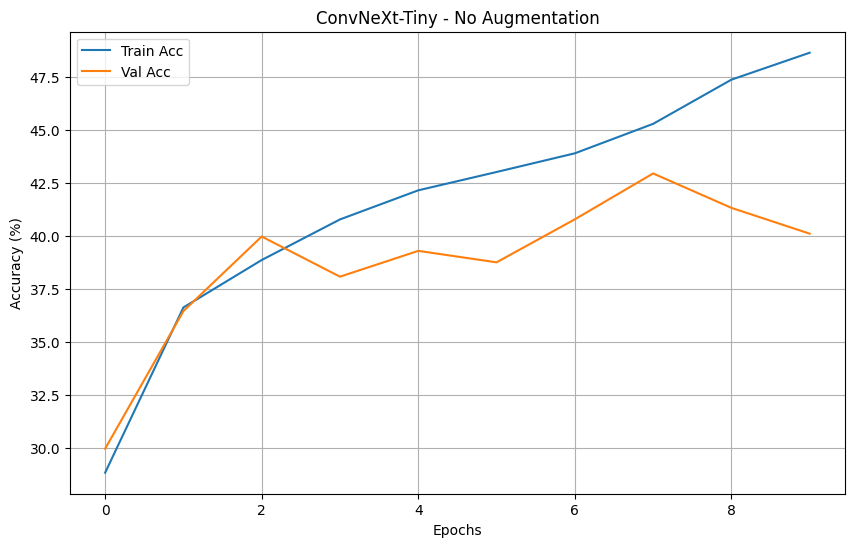


Final Test Accuracy: 44.84%


44.84029484029484

In [11]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "ConvNeXt-Tiny - No Augmentation")

evaluate_model(model, test_loader)